# Project 5: Predicting House Prices with Linear Regression
**Oasis Infobyte - Level 2**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries ready!')

Libraries ready!


## Step 1: Generate Housing Dataset

In [2]:
np.random.seed(42)
n = 800
size = np.random.randint(500, 5000, n)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)
age = np.random.randint(0, 50, n)
location = np.random.choice(['Suburban','Urban','Rural'], n, p=[0.4,0.4,0.2])
garage = np.random.choice([0,1], n, p=[0.3,0.7])

loc_mult = np.array([{'Urban':1.5,'Suburban':1.0,'Rural':0.65}[l] for l in location])
price = (size*1200 + bedrooms*300000 + bathrooms*150000 + garage*200000 - age*15000)*loc_mult
price = price + np.random.normal(0, price*0.08)
price = np.maximum(price, 500000)

df = pd.DataFrame({
    'Size_sqft': size, 'Bedrooms': bedrooms, 'Bathrooms': bathrooms,
    'Age_Years': age, 'Location': location, 'Garage': garage,
    'Price': np.round(price, -3)
})
df.loc[np.random.choice(df.index,20), 'Size_sqft'] = np.nan
print('Shape:', df.shape)
df.head()

Shape: (800, 7)


,Size_sqft,Bedrooms,Bathrooms,Age_Years,Location,Garage,Price
0,1360.0,5,2,30,Rural,0,1930000.0
1,4272.0,1,1,5,Urban,1,8233000.0
2,3592.0,1,1,18,Suburban,0,4119000.0
3,966.0,1,2,36,Urban,0,1831000.0
4,4926.0,1,2,3,Suburban,0,6227000.0


## Step 2: EDA & Cleaning

Missing: 18


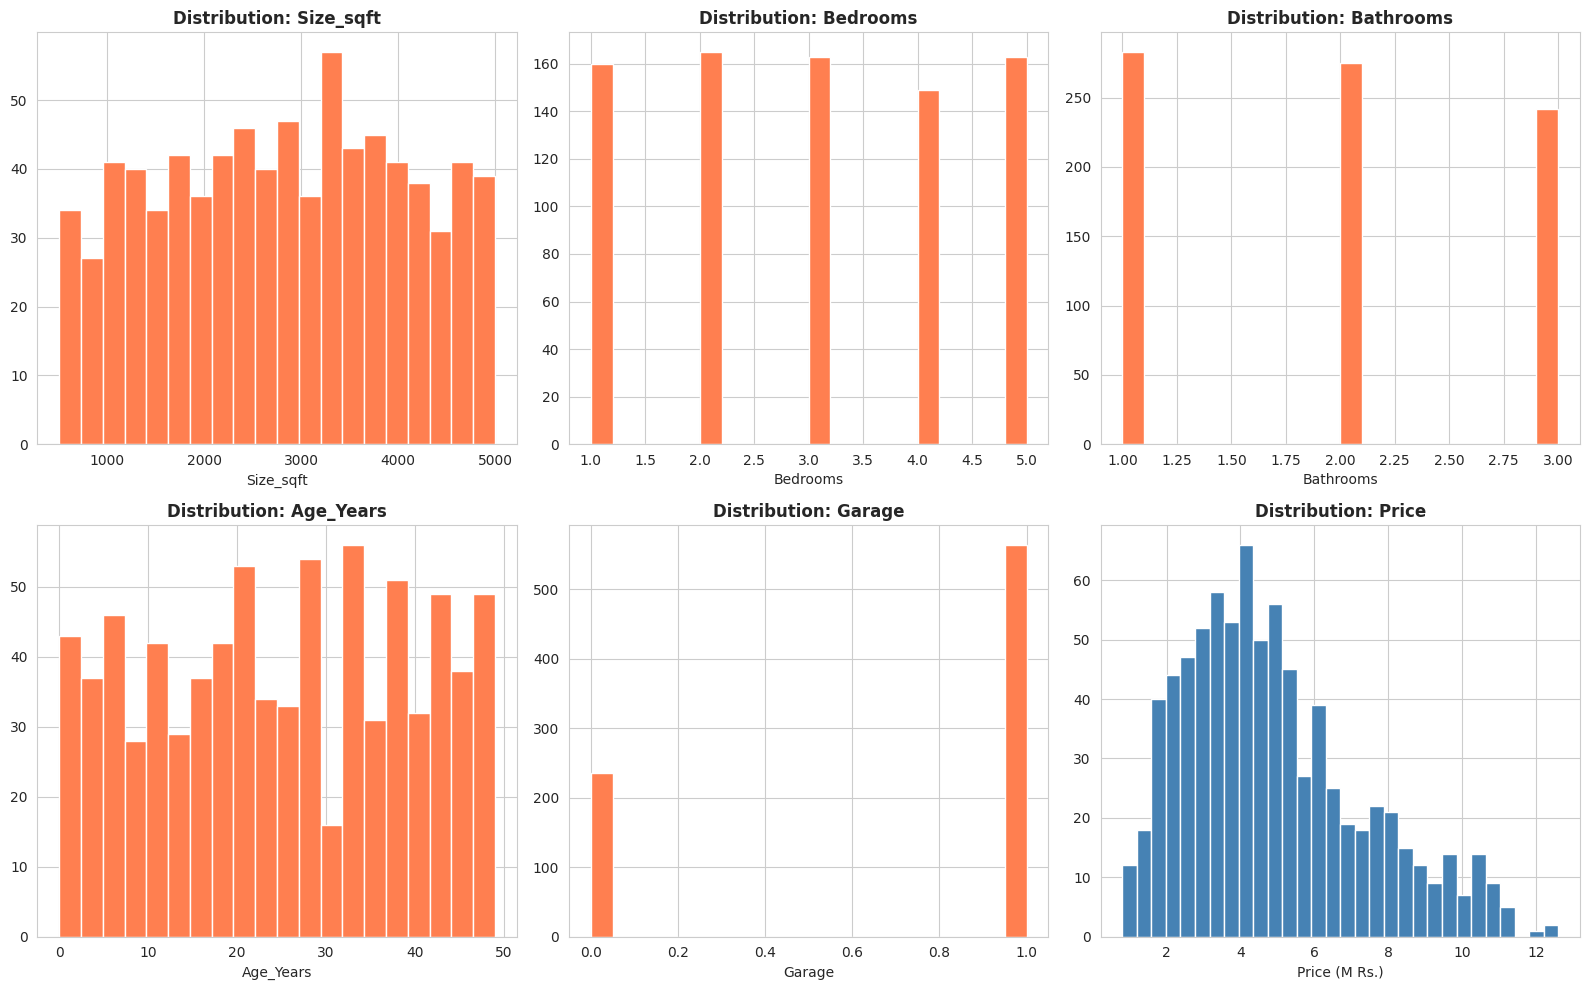

In [3]:
print('Missing:', df.isnull().sum().sum())
df['Size_sqft'].fillna(df['Size_sqft'].median(), inplace=True)

fig, axes = plt.subplots(2,3,figsize=(16,10))
for ax, col in zip(axes.flatten(), ['Size_sqft','Bedrooms','Bathrooms','Age_Years','Garage','Price']):
    if col == 'Price':
        ax.hist(df[col]/1e6, bins=30, color='steelblue', edgecolor='white')
        ax.set_xlabel('Price (M Rs.)')
    else:
        ax.hist(df[col], bins=20, color='coral', edgecolor='white')
        ax.set_xlabel(col)
    ax.set_title(f'Distribution: {col}', fontweight='bold')
plt.tight_layout(); plt.show()

## Step 3: Correlation Heatmap

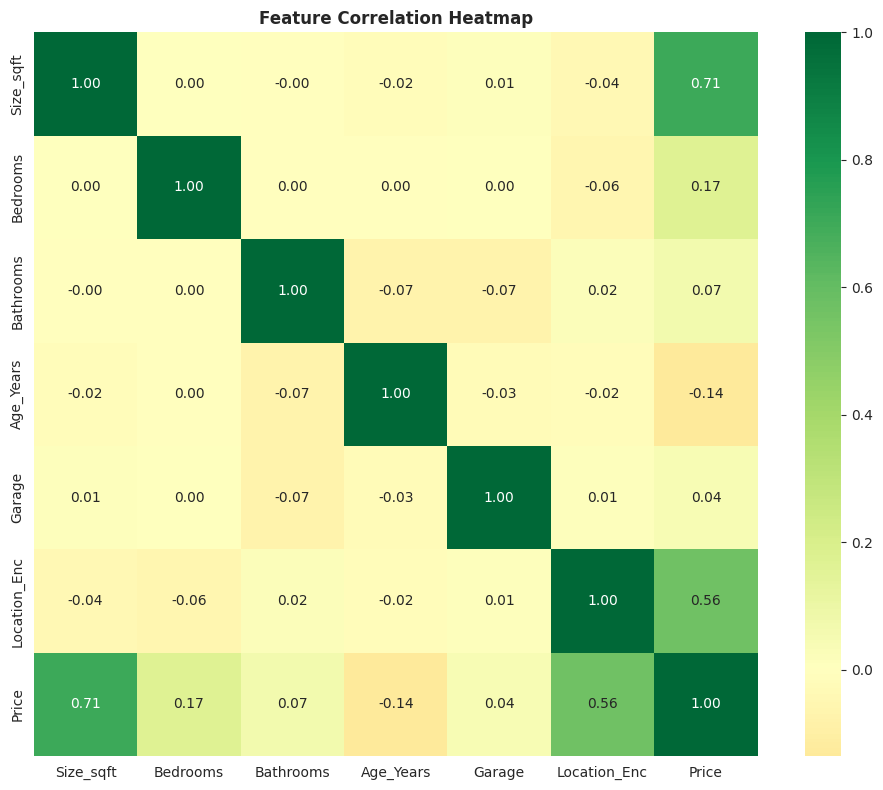

In [4]:
le = LabelEncoder()
df['Location_Enc'] = le.fit_transform(df['Location'])
num_cols = ['Size_sqft','Bedrooms','Bathrooms','Age_Years','Garage','Location_Enc','Price']
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', square=True, center=0)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

## Step 4: Train Linear Regression

In [5]:
features = ['Size_sqft','Bedrooms','Bathrooms','Age_Years','Garage','Location_Enc']
X = df[features]; y = df['Price']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_tr, y_train)
print('Model trained on', len(X_train), 'samples')

Model trained on 640 samples


## Step 5: Evaluate Model

R2 Score : 0.8867 (88.67%)
RMSE     : Rs.835,873
MAE      : Rs.608,435


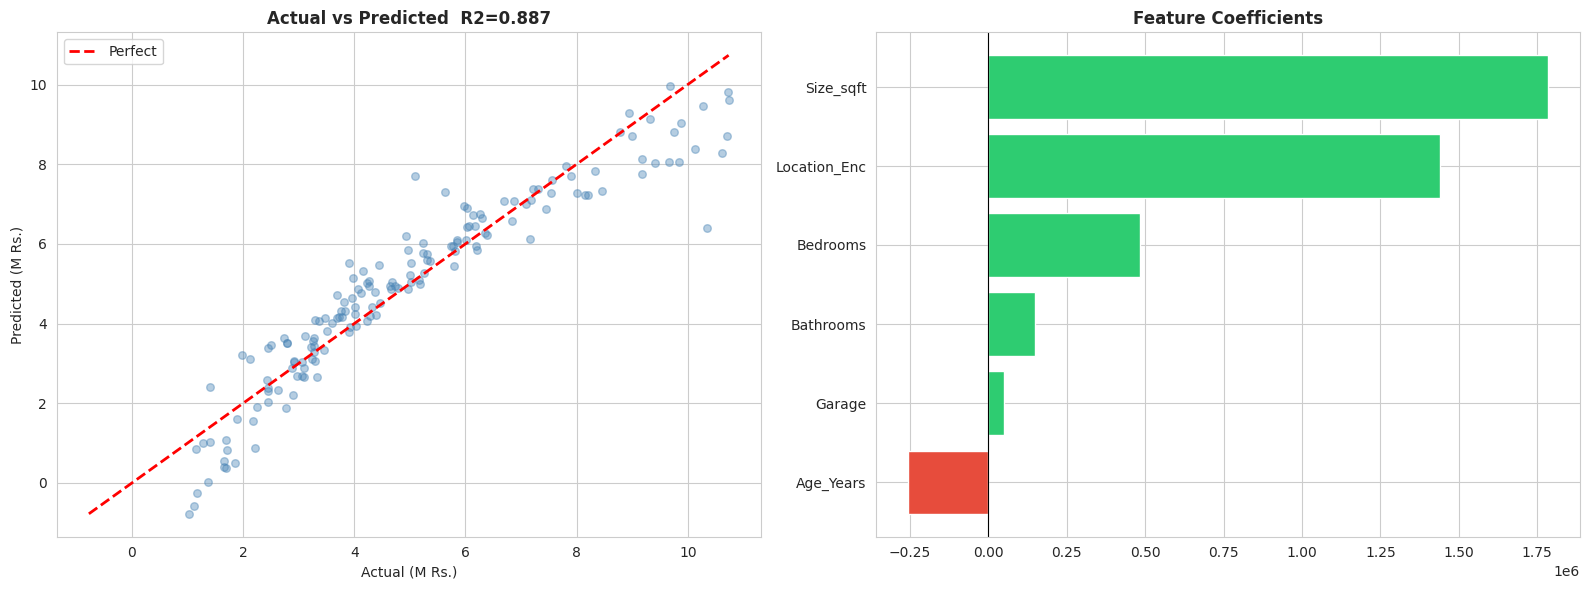

In [6]:
y_pred = model.predict(X_te)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f'R2 Score : {r2:.4f} ({r2*100:.2f}%)')
print(f'RMSE     : Rs.{rmse:,.0f}')
print(f'MAE      : Rs.{mae:,.0f}')

fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].scatter(y_test/1e6, y_pred/1e6, alpha=0.4, color='steelblue', s=30)
mn = min(y_test.min(),y_pred.min())/1e6; mx = max(y_test.max(),y_pred.max())/1e6
axes[0].plot([mn,mx],[mn,mx],'r--', linewidth=2, label='Perfect')
axes[0].set_title(f'Actual vs Predicted  R2={r2:.3f}', fontweight='bold')
axes[0].set_xlabel('Actual (M Rs.)'); axes[0].set_ylabel('Predicted (M Rs.)')
axes[0].legend()

coef_df = pd.DataFrame({'Feature':features,'Coef':model.coef_}).sort_values('Coef')
colors = ['#E74C3C' if c<0 else '#2ECC71' for c in coef_df['Coef']]
axes[1].barh(coef_df['Feature'], coef_df['Coef'], color=colors)
axes[1].set_title('Feature Coefficients', fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()

## Step 6: Predict New Houses

In [7]:
new = pd.DataFrame({
    'Size_sqft':[2000,1200,3500], 'Bedrooms':[3,2,5],
    'Bathrooms':[2,1,3], 'Age_Years':[5,20,1],
    'Garage':[1,0,1],
    'Location_Enc':[le.transform(['Urban'])[0], le.transform(['Rural'])[0], le.transform(['Suburban'])[0]]
})
preds = model.predict(scaler.transform(new))
for i, p in enumerate(preds):
    print(f"House {i+1}: Predicted Price = Rs.{p:,.0f}")

House 1: Predicted Price = Rs.5,621,363
House 2: Predicted Price = Rs.-184,599
House 3: Predicted Price = Rs.6,790,692
